In [1]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from random import shuffle
from resources.lattices import geometry, pStrainProperties, effProperties
from resources.calculations import calcUT, calcFT

In [2]:
### GLOBAL PATH INPUTS

pData = 'data/'

pAl          = pData + 'Al/'
pAK          = pAl + 'AK/'
pUTdisNodes  = pAK + 'Ductile-disNodes-FCC-12X16/'
pUTdisStruts = pAK + 'Ductile-disStruts-FCC-12X16/'
pFTdisNodes  = pAK + 'Fracture-disNodes/'

pTi    = pData + 'Ti/'
pTiTri = pTi + 'tri/'
pTiKag = pTi + 'kagome/'
pTiFCC = pTi + 'FCC/'
pTiHex = pTi + 'hex/'

# Load Data

In [6]:
PATH  = pTi
dis   = 'disNodes'     # disNodes, disStruts
MODEL = 'ductile'      # ductile, fracture, both

UT_CSVin  = PATH + f'Ductile-{dis}-IN.csv'
UT_CSVout = PATH + f'Ductile-{dis}-OUT.csv'
FT_CSVin  = PATH + f'Fracture-{dis}-IN.csv'
FT_CSVout = PATH + f'Fracture-{dis}-OUT.csv'

In [8]:
def load_data(inputs, outputs):
    IN_df = pd.read_csv(inputs, index_col=0).sort_index()
    OUT_df = pd.read_csv(outputs, index_col=0).sort_index()

    perIN_df = IN_df.loc[:0].T
    perIN_df = perIN_df.rename(columns={0: "in"})
    perOUT_df = OUT_df.iloc[:2].T.iloc[1:]
    perOUT_df.columns = ["x", "y"]

    dIN_df = IN_df - IN_df.iloc[0].values
    dIN_df = dIN_df.loc[:, ~(dIN_df == 0.0).all()].sort_index()
    dOUT_df = OUT_df - OUT_df.iloc[1].values
    dOUT_df = dOUT_df.drop(columns='0')  # dOUT_df['0'] = OUT_df['0']
    dOUT_df = dOUT_df.iloc[1:].sort_index()
    OUT_df = OUT_df.iloc[1:].sort_index()
    
    return IN_df, OUT_df, perIN_df, perOUT_df, dIN_df, dOUT_df

In [9]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_IN_df, UT_OUT_df, UT_perIN_df, UT_perOUT_df, UT_dIN_df, UT_dOUT_df = load_data(UT_CSVin, UT_CSVout)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_IN_df, FT_OUT_df, FT_perIN_df, FT_perOUT_df, FT_dIN_df, FT_dOUT_df = load_data(FT_CSVin, FT_CSVout)

In [18]:
UT_perIN_df

,in
0,277.128143
1,270.000000
2,268.467865
3,265.000000
4,268.467865
...,...
1989,-15.000000
1990,0.000000
1991,110.000000
1992,277.128143


# Geometry

In [19]:
LAT = PATH.split("/")[-2].lower()
l = 0.010
if LAT.lower() == "fcc" or LAT.lower() == "kagome":
    nnx = 20
elif LAT.lower() == "tri" or LAT.lower() == "hex":
    nnx = 30

geom = geometry(LAT, l, nnx, FTcalc=True)     #geom = [L, H, W, B, a0, ai, nny]

E = 123000e6  ## Pa
v = 0.3
rD = 0.2
E_pStrain, v_pStrain = pStrainProperties(E, v)
E_eff, v_eff = effProperties(LAT, E_pStrain, rD)

# Prep Data

In [20]:
def prep_UTdata(dIN_df, dOUT_df, perOUT_df, OUT_df):
    dIN = dIN_df.to_numpy()
    dOUT = dOUT_df.to_numpy()
    xOUT = np.linspace(0, max(perOUT_df.x.tolist()), len(dOUT[0]))
    
    ducts, strens, stiffs = [], [], []
    for i, row in OUT_df.iterrows():
        UT_df = pd.DataFrame({'x':np.insert(xOUT,0,row[0]), 'y_sm':row})
        ductility, strength, stiffness = calcUT(UT_df)
        
        ducts.append(ductility)
        strens.append(strength)
        stiffs.append(stiffness)
        
    props = [ducts, strens, stiffs]
    return dIN, dOUT, xOUT, props

def prep_FTdata(dIN_df, dOUT_df, perOUT_df, OUT_df, geom, E_eff):
    dIN = dIN_df.to_numpy()
    dOUT = dOUT_df.to_numpy()
    xOUT = np.linspace(0, max(perOUT_df.x.tolist()), len(dOUT[0]))
    
    Kjs, Ks, Ps, ds = [], [], [], []
    for indx, row in OUT_df.iterrows():
        FT_df = pd.DataFrame({'x':np.insert(xOUT,0,row[0]), 'y_sm':row})
        P, dd, K, Kj = calcFT(FT_df, geom, E_eff, n_Ks=1)
        
        Kjs.append(Kj[0])
        Ks.append(K[0])
        Ps.append(P)
        ds.append(dd)
    
    props = [Kjs, Ks, Ps, ds]
    return dIN, dOUT, xOUT, props

def find_outliers(data):
    mean = np.mean(data)
    stdev = np.std(data)
    
    outlier_idxs = [data.index(x) for x in data if (x < mean - 4*stdev) or (x > mean + 4*stdev) if data.index(x) != 0]
    return np.array(outlier_idxs, dtype="int")

def remove_outliers(dIN_r, dOUT_r, props_r, IN_df, OUT_df, dIN_df, dOUT_df):
    all_outlier_idxs = []
    for prop_r in props_r:
        idxs = find_outliers(data=prop_r)
        if len(idxs) == 0:
            continue
        for idx in idxs:
            all_outlier_idxs.append(idx)
    outlier_idxs = np.array(list(set(all_outlier_idxs)))
    
    if len(outlier_idxs) > 0:
        dIN = np.delete(dIN_r, outlier_idxs, axis=0)
        dOUT = np.delete(dOUT_r, outlier_idxs, axis=0)
        IN_df = IN_df.drop(IN_df.iloc[outlier_idxs].index)
        OUT_df = OUT_df.drop(OUT_df.iloc[outlier_idxs].index)
        dIN_df = dIN_df.drop(dIN_df.iloc[outlier_idxs].index)
        dOUT_df = dOUT_df.drop(dOUT_df.iloc[outlier_idxs].index)
        props = []
        for prop_r in props_r:
            prop = np.delete(prop_r, outlier_idxs, axis=0)
            props.append(prop)
    else:
        dIN, dOUT, props = dIN_r, dOUT_r, props_r
    
    return dIN, dOUT, props, IN_df, OUT_df, dIN_df, dOUT_df

def split_data(dIN, dOUT, split=0.85):
    idxs = list(range(len(dOUT)))
    shuffle(idxs)
    train_idxs = idxs[:int(split*len(dOUT))]
    test_idxs = [i for i in idxs if i not in train_idxs]
    
    train_in = dIN[train_idxs]
    test_in = dIN[test_idxs]
    train_out = dOUT[train_idxs]
    test_out = dOUT[test_idxs]
    
    return train_in, train_out, test_in, test_out

In [21]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_dIN_r, UT_dOUT_r, UT_xOUT, UT_props_r = prep_UTdata(UT_dIN_df, UT_dOUT_df, UT_perOUT_df, UT_OUT_df)
    UT_dIN, UT_dOUT, UT_props, UT_IN_df, UT_OUT_df, UT_dIN_df, UT_dOUT_df = remove_outliers(UT_dIN_r, UT_dOUT_r, UT_props_r, UT_IN_df, UT_OUT_df, UT_dIN_df, UT_dOUT_df)
    UT_train_in, UT_train_out, UT_test_in, UT_test_out = split_data(UT_dIN[1:], UT_dOUT[1:], split=0.85)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_dIN_r, FT_dOUT_r, FT_xOUT, FT_props_r = prep_FTdata(FT_dIN_df, FT_dOUT_df, FT_perOUT_df, FT_OUT_df, geom, E_eff)
    FT_dIN, FT_dOUT, FT_props, FT_IN_df, FT_OUT_df, FT_dIN_df, FT_dOUT_df = remove_outliers(FT_dIN_r, FT_dOUT_r, FT_props_r, FT_IN_df, FT_OUT_df, FT_dIN_df, FT_dOUT_df)
    FT_train_in, FT_train_out, FT_test_in, FT_test_out = split_data(FT_dIN[1:], FT_dOUT[1:], split=0.85)

# Plot Distribution & Identify Max, Min Simulations

In [22]:
def plot_frequency(raw_data, data, test):
    raw_data = np.array(data)
    data = np.array(data)
    
    if test == "UT":
        x_label = 'Normalized Ductility'
    elif test == "FT":
        x_label = 'Normalized Fracture Toughness ($K_{IC}$)'
    
    fig1, (ax1, ax2) = plt.subplots(1, 2)
    fig1.set_figheight(5)
    fig1.set_figwidth(15)
    
    ax1.set_title('Raw Data')
    ax1.axvline(x=raw_data[0]/raw_data[0], color='orangered', label="Perfect")
    ax1.hist(raw_data[1:]/raw_data[0], bins=int(len(data)/5), label='Disordered')
    ax1.set_ylabel('Frequency')
    ax1.set_xlabel(x_label)
    ax1.legend()
    
    ax2.set_title('Without Outliers')
    ax2.axvline(x=data[0]/data[0], color='orangered', label="Perfect")
    ax2.hist(data[1:]/data[0], bins=int(len(data)/5), label='Disordered')
    ax2.set_ylabel('Frequency')
    ax2.set_xlabel(x_label)
    ax2.legend()
    
    plt.show()

def plot_properties(x_data, y_data, test):
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    
    if test == "UT":
        title = "Uniaxial Tension"
        x_label = 'Normalized Ductility'
        y_label = 'Normalized Strength'
    elif test == "FT":
        title = "Compact Tension"
        x_label = 'Normalized Fracture Toughness ($K_{IC}$)'
        y_label = 'Normalized Displacement'
    
    fig1, ax1 = plt.subplots(1, 1)
    fig1.set_figheight(5)
    fig1.set_figwidth(10)
    
    ax1.set_title(title)
    ax1.scatter(x_data[0]/x_data[0], y_data[0]/y_data[0], label='Perfect')
    ax1.scatter(x_data[1:]/x_data[0], y_data[1:]/y_data[0], label='Disordered')
    ax1.axvline(x=1, linestyle='--')
    ax1.axhline(y=1, linestyle='--')
    ax1.set_ylabel(y_label)
    ax1.set_xlabel(x_label)
    ax1.legend()
    
    plt.show()

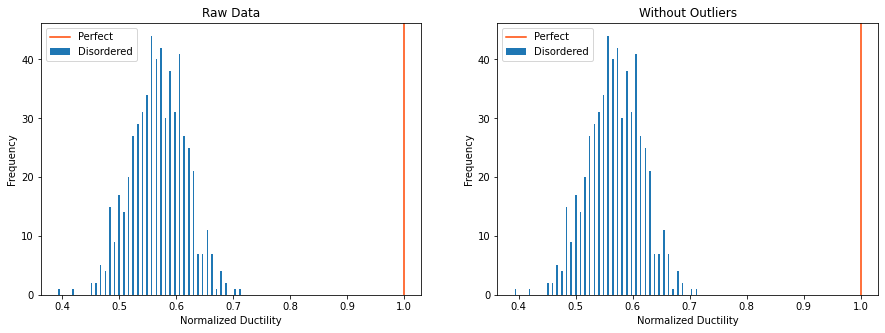

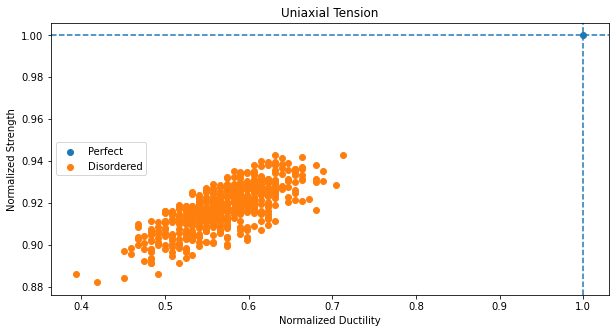

In [23]:
plot_freq = True
plot_props = True

dduct, sstr, sstiff = 0, 1, 2
kk, FF, dd = 0, 2, 3

U1, U2 = dduct, sstr
F1, F2 = kk, dd

if plot_freq:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_frequency(UT_props_r[U1], UT_props[U1], "UT")
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_frequency(FT_props_r[F1], FT_props[F1], "FT")

if plot_props:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_properties(UT_props[U1], UT_props[U2], "UT")
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_properties(FT_props[F1], FT_props[F2], "FT")

In [24]:
def locSims(prop, OUT_df):
    max_idx, min_idx = prop.index(max(prop[1:])), prop.index(min(prop[1:]))
    nSim_max, nSim_min = OUT_df.iloc[max_idx].name, OUT_df.iloc[min_idx].name
    return nSim_max, nSim_min

if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_nSim_max, UT_nSim_min = locSims(UT_props[0], UT_OUT_df)
    print(f"UT -- max: {UT_nSim_max}, min: {UT_nSim_min}")
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_nSim_max, FT_nSim_min = locSims(FT_props[0], FT_OUT_df)
    print(f"FT -- max: {FT_nSim_max}, min: {FT_nSim_min}")

UT -- max: 342, min: 281


# Plots UT and FT Curves

[208, 158, 521, 403, 251, 524, 325, 554, 235, 203]


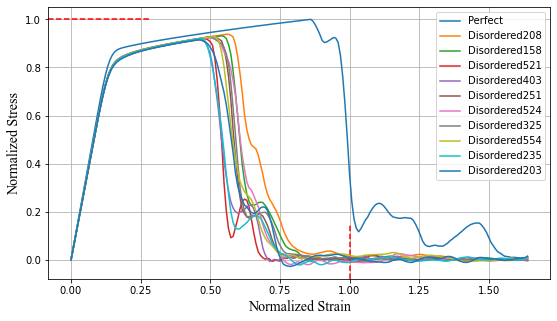

In [25]:
def plot_curve(OUT_df, xOUT, mode, idx=None, q=15):
    fig2, (ax1) = plt.subplots(1, 1)
    fig2.set_figheight(5)
    fig2.set_figwidth(9)
    
    p = OUT_df.loc[0].tolist()[1:]
    indx = int(OUT_df.loc[0].tolist()[0])
    ax1.plot(xOUT/xOUT[indx], [i/max(p) for i in p], label="Perfect")
    ax1.axvline(x=1, ymax=0.2, c='r', linestyle='--')
    ax1.axhline(y=1, xmax=0.2, c='r', linestyle='--')
    
    if idx:
        d = OUT_df.loc[idx].tolist()[1:]
        indx2 = int(OUT_df.loc[idx].tolist()[0])
        ax1.plot(xOUT/xOUT[indx], [i/max(p) for i in d], label=f'Disordered{idx}')
        ax1.axvline(x=xOUT[indx2]/xOUT[indx], ymax=0.2, c='g', linestyle='--')
        ax1.axhline(y=max(UTd)/max(UTp), xmax=0.2, c='g', linestyle='--')
        
    else:
        idxs = OUT_df.index.tolist()[1:]
        if q == 'all':
            idxs = idxs
        else:
            idxs = random.sample(idxs, q)
            print(idxs)
        
        for idxx in idxs:
            d = OUT_df.loc[idxx].tolist()[1:]
            ax1.plot(xOUT/xOUT[indx], [i/max(p) for i in d], label=f'Disordered{idxx}')
    
    if mode.lower() == "ut":
        ax1.set_ylabel('Normalized Stress', fontsize=14, fontname="Times New Roman")
        ax1.set_xlabel('Normalized Strain', fontsize=14, fontname="Times New Roman")
    if mode.lower() == "ft":
        ax1.set_ylabel('Normalized Force', fontsize=14, fontname="Times New Roman")
        ax1.set_xlabel('Normalized Displacement', fontsize=14, fontname="Times New Roman")
    
    if idx or q != 'all' and q <= 10:
        ax1.legend()
    ax1.grid()

    plt.show()

idx = None
q   = 10
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    plot_curve(UT_OUT_df, UT_xOUT, "ut", idx=idx, q=q)
    
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    plot_curve(FT_OUT_df, FT_xOUT, "ft", idx=idx, q=q)